### Architecture 2: Transfer-Learning Baseline

####  Train multiple classification architectures. At minimum, train and compare:
##### 2. A transfer-learning baseline using a pretrained ImageNet model (ResNet recommended; EfficientNet is also acceptable).
##### Evaluate and compare. Report classification accuracy on the held-out test split for each model. Include per-class accuracy or a confusion matrix to surface identity-level performance differences. Compare model size, training time, and accuracy in a single table.

#### 0. Environment setup (local Jupyter or Google Colab)
On **Colab**: `Runtime -> Change runtime type -> T4 GPU` (CPU also works, just slower), then run this cell.
By default it mounts Google Drive and uses (or clones) the repo at `MyDrive/IE7615-Group3-Project1`, so results,
logs and checkpoints persist after the session ends. Cloning the private repo needs a GitHub personal access token
saved as a Colab secret named `GITHUB_TOKEN` (key icon in the left sidebar). Locally, the cell just finds the repo root.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/rasmussenj03/IE7615-Group3-Project1.git"
COLAB_USE_DRIVE = True  # False -> clone into /content (outputs are lost when the runtime ends)
COLAB_REPO_DIR = ("/content/drive/MyDrive/IE7615-Group3-Project1" if COLAB_USE_DRIVE
                  else "/content/IE7615-Group3-Project1")

if "google.colab" in sys.modules:
    if COLAB_USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
    if not Path(COLAB_REPO_DIR, "src").is_dir():
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")  # Colab secret holding a GitHub access token
        clone = subprocess.run(["git", "clone", "-q", REPO_URL.replace("https://", f"https://{token}@"),
                                COLAB_REPO_DIR], capture_output=True)
        if clone.returncode != 0:
            raise RuntimeError("git clone failed - check the GITHUB_TOKEN secret and repo access")
        subprocess.run(["git", "-C", COLAB_REPO_DIR, "remote", "set-url", "origin", REPO_URL])
    os.chdir(COLAB_REPO_DIR)
else:
    root = Path.cwd()
    while not (root / "src" / "preprocessing.py").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
print("Project root:", PROJECT_ROOT)
print("PyTorch", torch.__version__, "| device:", "cuda - " + torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else "cpu")

Project root: /Users/pmodi/Desktop/P2/Rhea/NU Grad/IE 7615/Project 1/IE7615-Group3-Project1
PyTorch 2.8.0 | device: cpu


## 1. Import Pre-Processed Data

In [2]:
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision import models
from sklearn.metrics import f1_score, confusion_matrix
from src.preprocessing import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = [0, 1, 2]

loaders, class_names = get_dataloaders(batch_size=16)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

print("Classes:", class_names)
print("Train:", len(train_loader.dataset))
print("Validation:", len(val_loader.dataset))
print("Test:", len(test_loader.dataset))
print("Device:", device)

Classes: ['id_2336', 'id_2970', 'id_4422', 'id_7007']
Train: 59
Validation: 20
Test: 20
Device: cpu


## 2. Train Model

ResNet-18 pretrained on ImageNet is used as the transfer-learning architecture. The original ImageNet classification layer is replaced with a four-class output layer corresponding to the selected CelebA identities.

The pretrained network is fine-tuned using a smaller learning rate for the ResNet backbone and a larger learning rate for the new classification layer. Training is repeated using three random seeds for consistency with the other architectures.

In [3]:
from pathlib import Path

RESULTS_DIR = Path("results/resnet18")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: results/resnet18


In [4]:
def create_model():
    model = models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        len(class_names)
    )

    return model.to(device)

In [5]:
def train_model(model, epochs=20):

    criterion = nn.CrossEntropyLoss()

    backbone = [
        p for name, p in model.named_parameters()
        if not name.startswith("fc.")
    ]

    optimizer = torch.optim.AdamW([
        {"params": backbone, "lr": 1e-4},
        {"params": model.fc.parameters(), "lr": 1e-3}
    ])

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_acc = 0
    best_weights = None

    start = time.time()

    for epoch in range(epochs):

        # TRAIN
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * labels.size(0)
            train_correct += (
                outputs.argmax(1) == labels
            ).sum().item()

            train_total += labels.size(0)

        # VALIDATE
        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                val_correct += (
                    outputs.argmax(1) == labels
                ).sum().item()

                val_total += labels.size(0)

        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss / train_total)
        history["val_loss"].append(val_loss / val_total)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Acc: {train_acc:.3f} | "
            f"Val Acc: {val_acc:.3f}"
        )

    model.load_state_dict(best_weights)

    return model, history, time.time() - start

In [6]:
results = []
trained_models = {}
histories = {}

for seed in SEEDS:

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    print(f"\n--- Seed {seed} ---")

    model = create_model()

    model, history, training_time = train_model(model)

    trained_models[seed] = model
    histories[seed] = history

    # Save trained model
    torch.save(
        model.state_dict(),
        RESULTS_DIR / f"resnet18_seed{seed}.pt"
    )
    
    # Save training history
    pd.DataFrame(history).to_csv(
        RESULTS_DIR / f"history_seed{seed}.csv",
        index=False
    )

    # Test
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = model(images.to(device))
            predictions = outputs.argmax(1).cpu()

            y_true.extend(labels.numpy())
            y_pred.extend(predictions.numpy())

    accuracy = np.mean(
        np.array(y_true) == np.array(y_pred)
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    results.append({
        "seed": seed,
        "test_accuracy": accuracy,
        "macro_f1": f1,
        "training_time": training_time
    })

results_df = pd.DataFrame(results)
results_df

results_df.to_csv(
    RESULTS_DIR / "seed_results.csv",
    index=False
)


--- Seed 0 ---
Epoch 01 | Train Acc: 0.305 | Val Acc: 0.350
Epoch 02 | Train Acc: 0.780 | Val Acc: 0.750
Epoch 03 | Train Acc: 0.898 | Val Acc: 0.900
Epoch 04 | Train Acc: 0.966 | Val Acc: 0.900
Epoch 05 | Train Acc: 0.949 | Val Acc: 0.900
Epoch 06 | Train Acc: 1.000 | Val Acc: 0.900
Epoch 07 | Train Acc: 1.000 | Val Acc: 0.950
Epoch 08 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 09 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 10 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 11 | Train Acc: 0.983 | Val Acc: 1.000
Epoch 12 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 13 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 14 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 15 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 16 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 17 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 18 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 19 | Train Acc: 1.000 | Val Acc: 1.000
Epoch 20 | Train Acc: 1.000 | Val Acc: 1.000

--- Seed 1 ---
Epoch 01 | Train Acc: 0.305 | Val Acc: 0.500
Epoch 02 | Train Acc: 0

## 3. Evaluate Model

ResNet-18 is evaluated on the held-out test set using overall accuracy, Macro F1 score, per-class performance, and a confusion matrix. Mean performance across the three random seeds is reported for comparison with the Custom CNN and EfficientNet-B0 architectures.

In [7]:
mean_acc = results_df["test_accuracy"].mean()
std_acc = results_df["test_accuracy"].std()

mean_f1 = results_df["macro_f1"].mean()

print(f"Test Accuracy: {mean_acc:.1%} ± {std_acc:.1%}")
print(f"Macro F1: {mean_f1:.3f}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Average Training Time: {results_df['training_time'].mean():.1f} sec")

Test Accuracy: 83.3% ± 2.9%
Macro F1: 0.826
Parameters: 11,178,564
Average Training Time: 81.6 sec


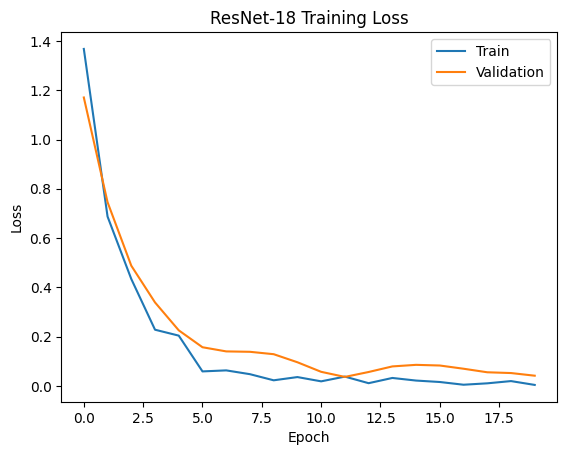

In [8]:
best_seed = int(
    results_df.loc[
        results_df["test_accuracy"].idxmax(),
        "seed"
    ]
)

history = histories[best_seed]

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-18 Training Loss")
plt.legend()

plt.savefig(
    RESULTS_DIR / "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

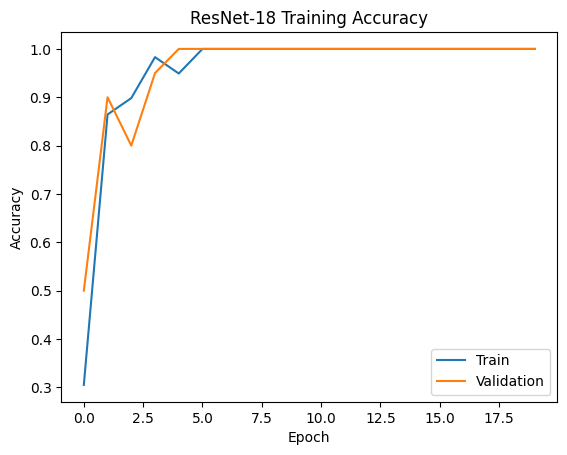

In [9]:
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet-18 Training Accuracy")
plt.legend()

plt.savefig(
    RESULTS_DIR / "training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

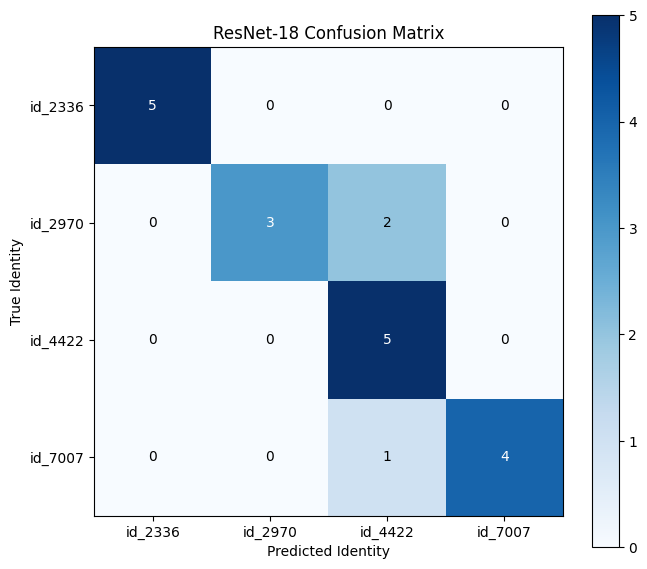

Per-Class Accuracy:
id_2336: 100.0%
id_2970: 60.0%
id_4422: 100.0%
id_7007: 80.0%


In [10]:
best_model = trained_models[best_seed]

y_true = []
y_pred = []

best_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = best_model(images.to(device))
        predictions = outputs.argmax(1).cpu()

        y_true.extend(labels.numpy())
        y_pred.extend(predictions.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap="Blues")

# Labels
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Identity")
ax.set_ylabel("True Identity")
ax.set_title("ResNet-18 Confusion Matrix")

# Add values inside each box
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.colorbar(im)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

per_class_results = []

print("Per-Class Accuracy:")

for i, name in enumerate(class_names):

    mask = y_true == i

    accuracy = (
        y_true[mask] == y_pred[mask]
    ).mean()

    per_class_results.append({
        "identity": name,
        "accuracy": accuracy
    })

    print(f"{name}: {accuracy:.1%}")

per_class_df = pd.DataFrame(per_class_results)

## ResNet-18 Findings

- ResNet-18 achieved a mean test accuracy of **83.3% ± 2.9%** across the three seeds, with a mean Macro F1 score of **0.826**.
- Training converged quickly. Training and validation accuracy reached high levels within the first few epochs, while both losses decreased substantially.
- The training curves show strong convergence with only a small gap between training and validation loss. Validation accuracy remained at or near **100%** for most later epochs.
- Performance was relatively stable across seeds, with test accuracy ranging from **80% to 85%**.
- Per-class performance was strongest for **id_2336** and **id_4422**, both achieving **100% accuracy**. Performance was lower for **id_2970 (60%)** and **id_7007 (80%)**.
- The confusion matrix shows that the primary classification errors involved **id_2970 being predicted as id_4422**, indicating that these two identities were the most difficult for ResNet-18 to distinguish.
- Overall, the results demonstrate that ImageNet-pretrained ResNet-18 transfers effectively to the small CelebA identity dataset.